In [10]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_diabetes
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

### Task 1: Ridge Regression & Alpha Sensitivity Analysis (ใช้ California Housing Dataset)
1. โหลดชุดข้อมูล fetch_california_housing และแบ่งข้อมูลด้วย train_test_split (test_size=0.2)
2. สร้างโมเดล Ridge Regression และทดลองปรับค่า α (λ) ได้แก่ 0.01, 1.0, 100.0, 10000.0 [cite: 1]
3. บันทึกค่า Coefficients (Slope) และประเมินผลด้วยค่า MSE และ MAE Loss บน Test Set [cite: 1]
4. อธิบายว่าการเพิ่มค่า α ส่งผลต่อความอ่อนไหว (Sensitivity) และ Variance ของโมเดลอย่างไร [cite: 1]

### อธิบายว่าการเพิ่มค่า α ส่งผลต่อความอ่อนไหว (Sensitivity) และ Variance ของโมเดลอย่างไร 
#### ANS: sensitivity จะลดลง ค่า alpha สูงขึ้น จะกดค่า coef ให้เข้าใกล้ 0 ส่งผลให้ model มีความเสถียรขึ้น อ่อนไหวข้อมูลน้อยลง 
#### variance ลดลง ถ้า alpha ต่ำจะทำให้เกิด overfitting ทำให้ variance สูงขึ้น alpha สูงขึ้นทำให้ model จดจำ noise ทำให้ variance ลดลง ส่งผลให้ model มีความเสถียรขึ้น ลดปัญหา Overfitting 


### sensitivity: การเปลี่ยนแปลงของคำตอบเมื่อข้อมูลอินพุตเปลี่ยนไปเล็กน้อย 
- เมื่อ Coefficients ถูกกดให้มีขนาดเล็กมาก โมเดลจะไม่ตอบสนองรุนแรงต่อความผันผวนเล็กๆ น้อยๆ ของตัวแปรต้น ทำให้โมเดล "เสถียรขึ้น และอ่อนไหวต่อข้อมูลน้อยลง"
### Variance: ความแตกต่างของผลการทำนาย เมื่อเปลี่ยนชุดข้อมูล Training Data ไปเป็นชุดอื่น
- เมื่อ $\alpha$ ต่ำมาก (ใกล้ 0): โมเดลจะพยายามฟิตข้อมูล Train ให้ดีที่สุดจนเกิด Overfitting ส่งผลให้ Variance สูง
- เมื่อเพิ่ม $\alpha$ สูงขึ้น: บทลงโทษจะจำกัดไม่ให้โมเดลจดจำ Noise หรือรายละเอียดย่อยเกินไป ทำให้ Variance ลดลง

In [3]:
# step 1
califonia = fetch_california_housing()
x = califonia.data
y = califonia.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# step 2 
alphas = [0.01, 1.0, 5.0, 100.0, 1000.0]
mse_results = []
mae_results = []
coef_results = []
for i in alphas:
    model_ridge = Ridge(alpha=i)
    model_ridge = model_ridge.fit(x_train, y_train)
    
    # step 3 
    y_pred = model_ridge.predict(x_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mse_results.append(mse)

    mae = mean_absolute_error(y_test, y_pred)
    mae_results.append(mae)

    coef_results.append(model_ridge.coef_)


df_result = pd.DataFrame({
    'Alpha': alphas,
    'MSE': mse_results,
    'MAE': mae_results
})

print("=== Coefficients (Slopes) for Each Alpha ===")
df_coef = pd.DataFrame(
    coef_results,
    columns=califonia.feature_names,
    index=[f"Alpha = {a}" for a in alphas]
)

df_coef

=== Coefficients (Slopes) for Each Alpha ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
Alpha = 0.01,0.432162,0.009425,-0.098235,0.595815,-5.638787e-06,-0.003410,-0.425612,-0.436024
Alpha = 1.0,0.432053,0.009427,-0.098024,0.594709,-5.630813e-06,-0.003410,-0.425585,-0.435981
Alpha = 5.0,0.431617,0.009435,-0.097182,0.590282,-5.598677e-06,-0.003409,-0.425473,-0.435807
Alpha = 100.0,0.422997,0.009625,-0.080444,0.501772,-4.870735e-06,-0.003394,-0.421912,-0.430911
Alpha = 1000.0,0.396664,0.010968,-0.027297,0.206637,2.244617e-07,-0.003428,-0.368672,-0.370743


In [4]:
print("=== Evaluation Results ===")
df_result.head()

=== Evaluation Results ===


,Alpha,MSE,MAE
0,0.01,0.492805,0.523718
1,1.00,0.492822,0.523730
2,5.00,0.492891,0.523777
3,100.00,0.494545,0.524798
4,1000.00,0.506491,0.530459


## Task 2: Lasso Regression & Feature Elimination (ใช้ Diabetes Dataset)
1. โหลดชุดข้อมูล load_diabetes
2. สร้างโมเดล Lasso Regression และทดลองปรับค่า α ในช่วง 0.01, 0.1, 1.0, 5.0
3. สังเกตการเปลี่ยนแปลงของค่า Coefficients ในแต่ละ Feature (เช่น ค่าผลเลือด s1-s6)
4. แสดงรายการ Feature ที่ถูกตัดออก (Slope กลายเป็น 0) และสรุปว่า Feature ใดมีความสำคัญต่อการพยากรณ์โรคเบาหวานมากที่สุด

In [5]:
# step 1
diabet = load_diabetes()
x = diabet.data
y = diabet.target
x_train1, x_test1, y_train1, y_test1 = train_test_split(x, y, test_size=0.2,random_state=42)

# step 2 
alphas2 = [0.01, 0.1, 1.0, 2.0, 3.0, 5.0]
coef = []
for i in alphas2:
    lasso = Lasso(alpha = i)
    lasso.fit(x_train1, y_train1)
    y_pred2 = lasso.predict(x_test1)

    # step 3
    coef.append(lasso.coef_)

# step 4
df_lasso = pd.DataFrame({
    "Features": diabet.feature_names, 
    "Coefficient": lasso.coef_
})

dropped_features = df_lasso.sort_values(by="Coefficient")
dropped_features

,Features,Coefficient
0,age,0.0
1,sex,0.0
2,bmi,0.0
3,bp,0.0
4,s1,0.0
5,s2,0.0
6,s3,0.0
7,s4,0.0
8,s5,0.0
9,s6,0.0


### การดูค่า Coefficient และบอกความสำคัญของ Feature
- ต้องดูตอนที่ค่า coefficient เป็น 0 ตัวสุดท้าย ถึงจะได้ว่าเป็น feature สำคัญที่สุด
### สรุปว่า Feature ใดมีความสำคัญต่อการพยากรณ์โรคเบาหวานมากที่สุด
#### ANS: feature bmi มีความสำคัญต่อการพยาการณ์มากที่สุด

In [6]:
df_all = pd.DataFrame(coef, columns=diabet.feature_names)
df_all.insert(0, "Alpha", alphas2)
df_all

,Alpha,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.01,35.347451,-231.906664,551.303242,341.313469,-483.567140,165.990532,-25.834899,216.875803,566.815003,49.702475
1,0.10,0.000000,-152.664779,552.697775,303.365158,-81.365007,-0.000000,-229.255776,0.000000,447.919525,29.642617
2,1.00,0.000000,-0.000000,413.431848,34.830515,0.000000,0.000000,-0.000000,0.000000,258.152894,0.000000
3,2.00,0.000000,0.000000,101.161526,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,3.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,5.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Task 3: Elastic Net & Cross Validation Tuning (ใช้ Diabetes Dataset)
1. สร้างโมเดล Elastic Net Regression บนชุดข้อมูล Diabetes
2. ใช้ 10-Fold Cross Validation (GridSearchCV) เพื่อค้นหาค่า alpha ([0.01, 0.1, 1.0, 10.0]) และ l1_ratio ([0.1, 0.3, 0.5, 0.7, 0.9]) ที่เหมาะสมที่สุด
     - สร้าง Pipeline (สเกลข้อมูล + โมเดล ElasticNet) การทำ Scaling ใน Pipeline จะช่วยป้องกัน Data Leakage ใน Cross Validation
     - กำหนด Parameter Grid
     - ตั้งค่าและรัน GridSearchCV
     - สั่งรันการค้นหาค่าที่ดีที่สุดบน X_train
     - ทำนายผลบน Test Set ด้วยโมเดลที่ดีที่สุด
3. เปรียบเทียบประสิทธิภาพ (Test MSE/MAE) ระหว่าง Best Elastic Net, Ridge และ Lasso
   - Define Parameter Grid สำหรับ Ridge และ Lasso
   - Ridge GridSearch
   - Lasso GridSearch
   - ดึง Best Estimator ของแต่ละโมเดล
   - ทำนายผลบน Test Set
   - คำนวณ Test MSE
   - คำนวณ Test MAE
   - สรุปเปรียบเทียบผลลัพธ์ลงตาราง

In [7]:
# step 1
dia = load_diabetes()
x = dia.data
y = dia.target
x_train2, x_test2, y_train2, y_test2 = train_test_split(x, y, test_size=0.2, random_state=42)

# step 2 
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# step 2.1
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(random_state=42))
])

# step 2.2 
param_grid = {
    'elasticnet__alpha' :[0.01, 0.1, 1.0, 10.0],
    'elasticnet__l1_ratio' :[0.1, 0.3, 0.5, 0.7, 0.9]
    
}

# step 2.3 
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv = 10,
    scoring='neg_mean_squared_error',
    n_jobs=-1  # ใช้ cpu ทุก core
)

# step 2.4
grid_search.fit(x_train2, y_train2)

print("Best Alpha & L1 Ratio: ", grid_search.best_params_)
print("Best CV Score (MSE): ", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_etn = best_model.predict(x_test2)

# step 2.5
test_score = best_model.score(x_test2, y_test2)
print(f"Test Set R^2 Score: {test_score:.4f}")

Best Alpha & L1 Ratio:  {'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.3}
Best CV Score (MSE):  -3112.516576127309
Test Set R^2 Score: 0.4553


In [8]:
# step 3.1 
param_grid_ridge = {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
param_grid_lasso = {'lasso__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

# step 3.2
pipe_ridge = Pipeline([('scaler', StandardScaler()) , ('ridge', Ridge(random_state=42))])
search_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=10, scoring= 'neg_mean_squared_error', n_jobs=-1)
search_ridge.fit(x_train2, y_train2)

# step 3.3
pipe_lasso = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(random_state=42))])
search_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
search_lasso.fit(x_train2, y_train2)

# step 3.4
best_enet = grid_search.best_estimator_
best_ridge = search_ridge.best_estimator_
best_lasso = search_lasso.best_estimator_

# step 3.5
pred_enet = best_enet.predict(x_test2)
pred_ridge = best_ridge.predict(x_test2)
pred_lasso = best_lasso.predict(x_test2)

# step 3.6 
mse_enet = mean_squared_error(y_test2, pred_enet)
mse_ridge = mean_squared_error(y_test2, pred_ridge)
mse_lasso = mean_squared_error(y_test2, pred_lasso)

# step 3.7 
mae_ent = mean_absolute_error(y_test2, pred_enet)
mae_ridge = mean_absolute_error(y_test2, pred_ridge)
mae_lasso = mean_absolute_error(y_test2, pred_lasso)

# step 3.8
results = pd.DataFrame({
    'Model': ['Elastic Net', 'Ridge', 'Lasso'],
    'Best Params': [grid_search.best_params_, search_ridge.best_params_, search_lasso.best_params_],
    'Test MSE': [mse_enet, mse_ridge, mse_lasso],
    'Test MAE': [mae_ent, mae_ridge, mae_lasso]
})

print(results.to_string(index=False))

      Model                                              Best Params    Test MSE  Test MAE
Elastic Net {'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.3} 2886.113997 42.826030
      Ridge                                   {'ridge__alpha': 10.0} 2875.778718 42.856825
      Lasso                                    {'lasso__alpha': 0.1} 2884.624289 42.805234


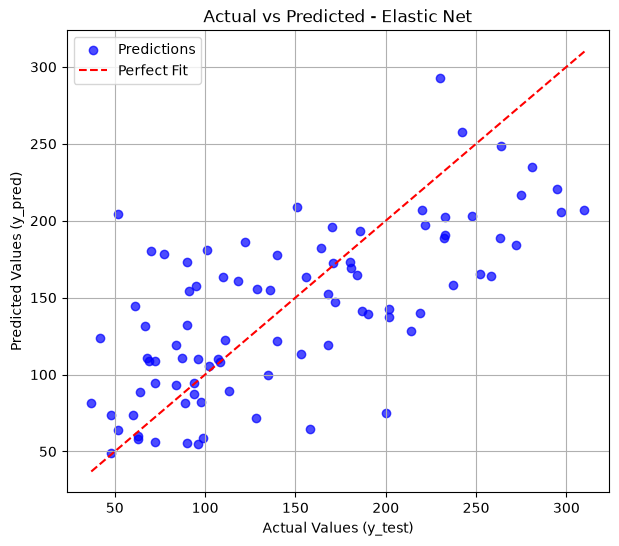

In [17]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test2, pred_enet, alpha=0.7, color='b', label='Predictions')

# เส้น Perfect Prediction (ถ้าทำนายตรงเป๊ะ จุดทั้งหมดจะอยู่บนเส้นนี้)
min_val = min(min(y_test2), min(pred_enet))
max_val = max(max(y_test2), max(pred_enet))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')

plt.title("Actual vs Predicted - Elastic Net")
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.legend()
plt.grid(True)
plt.show()

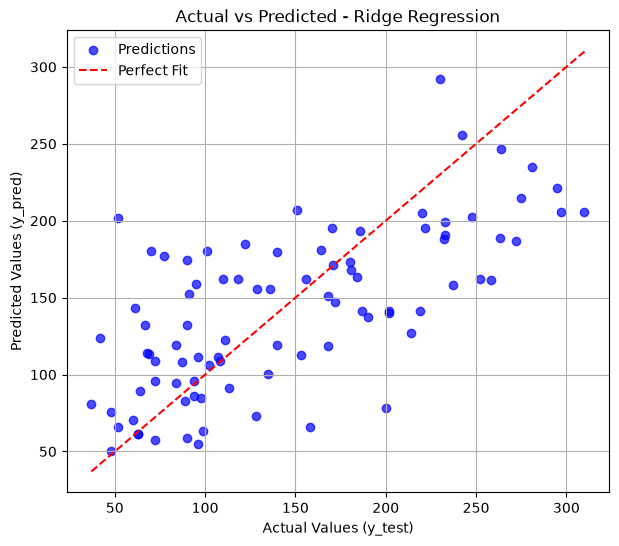

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test2, pred_ridge, alpha=0.7, color='b', label='Predictions')

# เส้น Perfect Prediction (ถ้าทำนายตรงเป๊ะ จุดทั้งหมดจะอยู่บนเส้นนี้)
min_val = min(min(y_test2), min(pred_ridge))
max_val = max(max(y_test2), max(pred_ridge))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')

plt.title("Actual vs Predicted - Ridge Regression")
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.legend()
plt.grid(True)
plt.show()

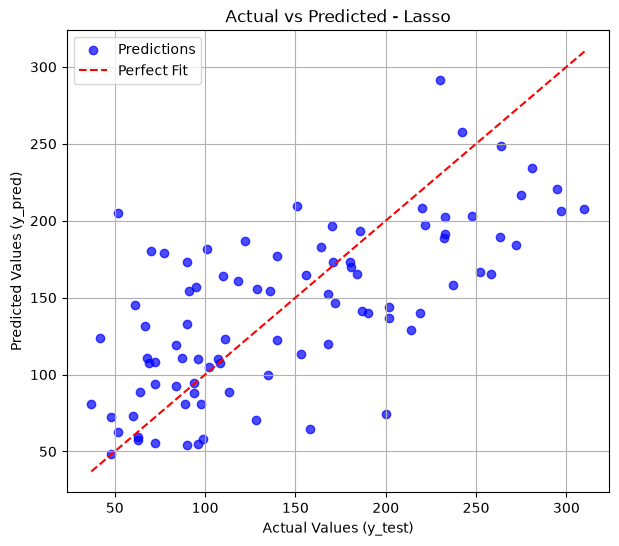

In [14]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test2, pred_lasso, alpha=0.7, color='b', label='Predictions')

# เส้น Perfect Prediction (ถ้าทำนายตรงเป๊ะ จุดทั้งหมดจะอยู่บนเส้นนี้)
min_val = min(min(y_test2), min(pred_lasso))
max_val = max(max(y_test2), max(pred_lasso))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')

plt.title("Actual vs Predicted - Lasso")
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.legend()
plt.grid(True)
plt.show()